In [1]:
%pip install pandas numpy matplotlib seaborn folium


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached folium-0.20.0-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached branca-0.8.2-py3-none-any.whl.metadata (1.7 kB)
  Using cached xyzservices-2026.3.0-py3-none-any.whl.metadata (4.1 kB)
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.3 MB 2.0 MB/s eta 0:00:06
   --- ------------------------------------ 1.0/11.3 MB 2.0 MB/s eta 0:00:06
   ----- ---------------------------------- 1.6/11.3 MB 1.9 MB/s eta 0:00:06
   ------ --------------------------------- 1.8/11.3 MB 1.8 MB/s eta 0:00:06
   ------- -------------------------------- 2.1/11.3 MB 1.8 MB/s eta 0:00:06
   --------- ------------------------------ 2.6/11.3 MB 1.8 MB/s eta 0:00:05
   ----------- ---------------------------- 3.1/11.3 MB 1.9 MB/s e

In [4]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('NY-House-Dataset.csv')

# 1. Filter data (Ensure no zero-size properties to avoid division errors)
df = df[df['PROPERTYSQFT'] > 0]

# 2. Create the Price per Sqft column
df['price_per_sqft'] = df['PRICE'] / df['PROPERTYSQFT']

# 3. Create Maps, Min, Max (Using NumPy Percentiles for the Bins)
# This matches the "Bin 0 to 4" output in your image
bins = np.percentile(df['price_per_sqft'], [0, 20, 40, 60, 80, 100])

print("Price per Sqft Bins:")
for i in range(5):
    print(f"Bin {i}: ${bins[i]:.2f} - ${bins[i+1]:.2f}")

# Show the first few rows to verify
df[['PRICE', 'PROPERTYSQFT', 'price_per_sqft', 'LATITUDE', 'LONGITUDE']].head()

Price per Sqft Bins:
Bin 0: $1.14 - $291.91
Bin 1: $291.91 - $416.67
Bin 2: $416.67 - $583.74
Bin 3: $583.74 - $967.74
Bin 4: $967.74 - $214748.36


,PRICE,PROPERTYSQFT,price_per_sqft,LATITUDE,LONGITUDE
0,315000,1400.0,225.000000,40.761255,-73.974483
1,195000000,17545.0,11114.277572,40.766393,-73.980991
2,260000,2015.0,129.032258,40.541805,-74.196109
3,69000,445.0,155.056180,40.761398,-73.974613
4,55000000,14175.0,3880.070547,40.767224,-73.969856


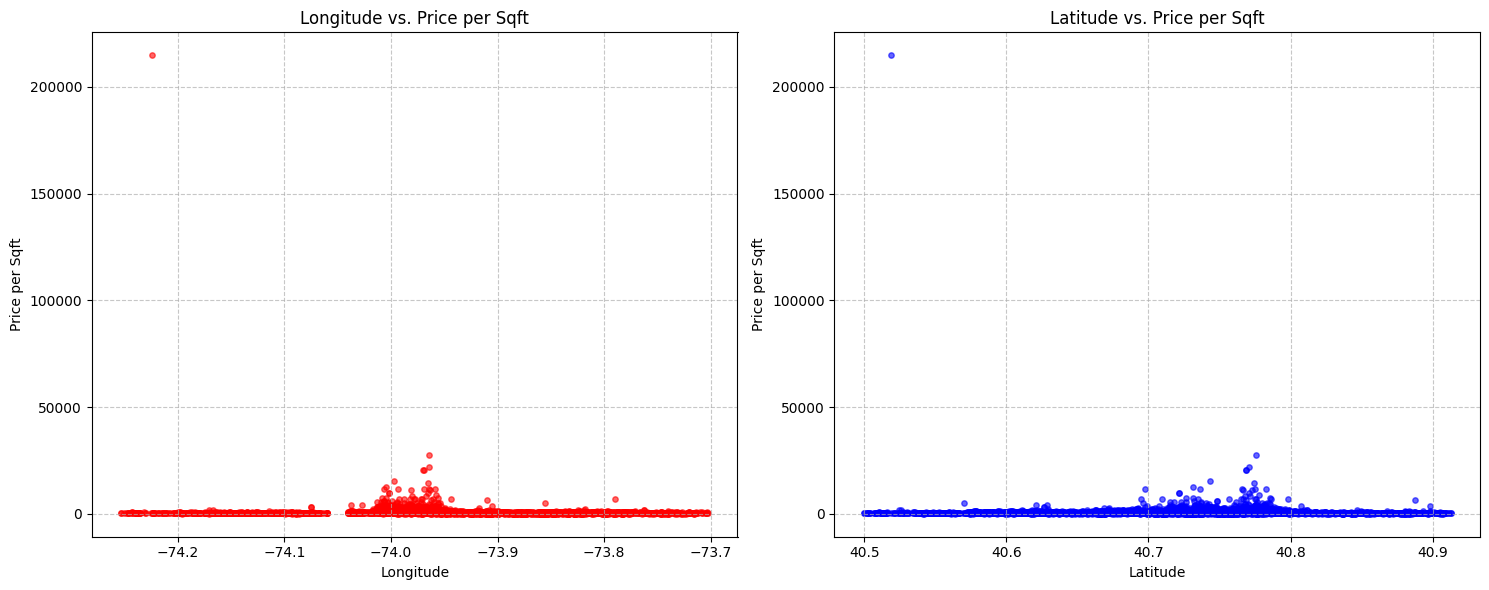

In [5]:
import matplotlib.pyplot as plt

# Create a figure with two side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Red Plot: Longitude vs. Price per Sqft
ax1.scatter(df['LONGITUDE'], df['price_per_sqft'], color='red', s=15, alpha=0.6)
ax1.set_title('Longitude vs. Price per Sqft')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Price per Sqft')
ax1.grid(True, linestyle='--', alpha=0.7)

# Blue Plot: Latitude vs. Price per Sqft
ax2.scatter(df['LATITUDE'], df['price_per_sqft'], color='blue', s=15, alpha=0.6)
ax2.set_title('Latitude vs. Price per Sqft')
ax2.set_xlabel('Latitude')
ax2.set_ylabel('Price per Sqft')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

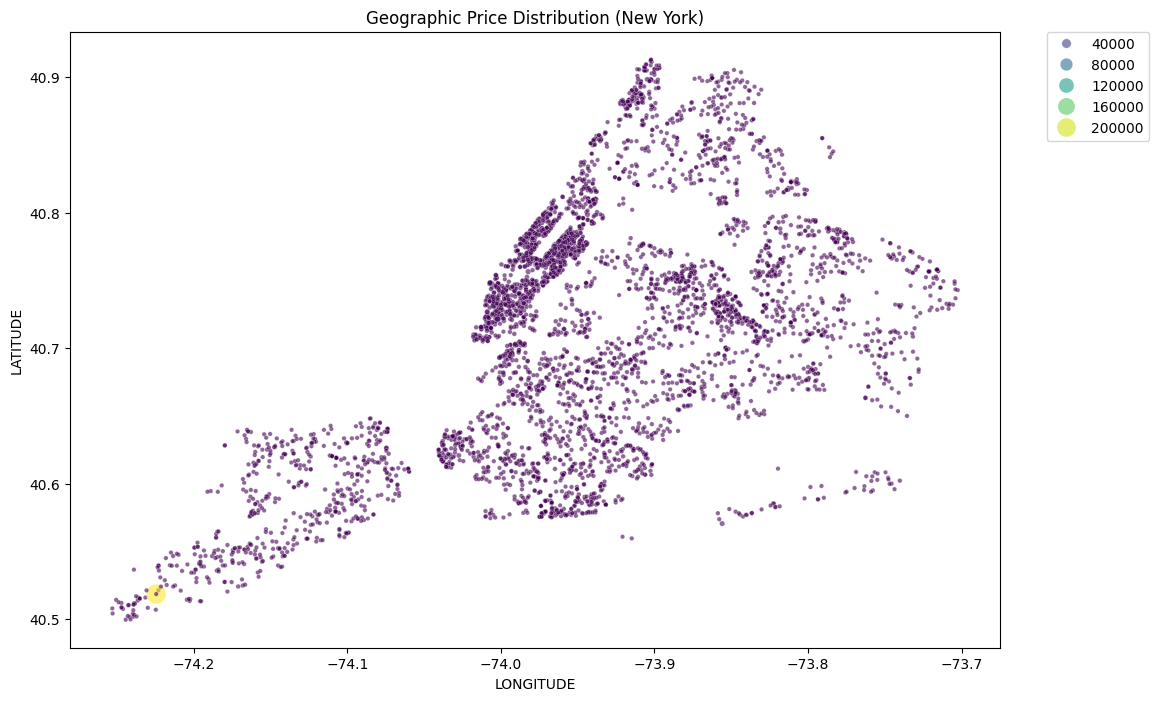

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
# We use the longitude/latitude as coordinates and price for color (hue)
scatter = sns.scatterplot(
    data=df, 
    x='LONGITUDE', 
    y='LATITUDE', 
    hue='price_per_sqft', 
    palette='viridis', 
    size='price_per_sqft', 
    sizes=(10, 200),
    alpha=0.6
)

plt.title('Geographic Price Distribution (New York)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

In [10]:
import folium
from IPython.display import display

# Center the map on New York
m = folium.Map(location=[40.7128, -74.0060], zoom_start=11)

# To avoid crashing the map, let's show the top 100 cheapest apartments 
# (As the image mentions "Cheapest Apartments")
cheapest = df.nsmallest(100, 'price_per_sqft')

for _, row in cheapest.iterrows():
    folium.Marker(
        location=[row['LATITUDE'], row['LONGITUDE']],
        popup=f"Price/sqft: ${row['price_per_sqft']:.2f}",
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(m)

# Display the map
m
display(m)
m.save("ny_map.html")
print("Map saved to ny_map.html. Open this file in your browser!")

Map saved to ny_map.html. Open this file in your browser!
